# Figure 4 (review variant) · Live fast mode mapping, stiff probe only

Review variant of main-text Fig. 4 using only the stiff probe (run R2, 500 nN): one equispaced
pass of 8 positions in 9.6 min, reconstructed afterwards (rank-r Chebyshev, `activemodemap.lowrank`),
scored on a separate capture of 7 midpoints the design never visited. Scores from notebook 04
(`results/fig4_live_fmm.csv`, Phase 2b re-score). Positions are in the stage frame (the wide-band
captures have no dense-map frame anchor of their own).

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
L4 = pd.read_csv(F.config.RESULTS_DIR / "fig4_live_fmm.csv")
NAME = "SCM-PIT-B R2"; Q = L4[L4.probe == NAME].sort_values("rank")
best = Q.loc[Q.nrmse.idxmin()]
d, v = F.load("scmpitB_r2_wb_fast"), F.load("scmpitB_r2_wb_valid")
r = int(best["rank"])
Zp, _ = recon.cross_capture(d.x_um, d.Z[0], v.x_um, arm="lowrank", rank=r)
print("design x:", np.round(d.x_um, 1), "\nvalidation x:", np.round(v.x_um, 1))
Q[["rank", "N", "nrmse", "within_3dB", "phase_mae_deg", "nrmse_CR1", "nrmse_CR2", "nrmse_CR3"]].round(2)

design x: [ 72.   94.9 117.7 140.6 163.4 186.3 209.1 232. ] 
validation x: [ 83.4 106.3 129.2 152.  174.9 197.7 220.6]


,rank,N,nrmse,within_3dB,phase_mae_deg,nrmse_CR1,nrmse_CR2,nrmse_CR3
8,3,8,37.27,0.58,4.30,9.97,39.59,46.98
9,4,8,29.56,0.78,7.96,11.32,17.00,46.94
10,5,8,19.05,0.99,3.37,11.45,19.62,23.12
11,6,8,20.27,0.99,3.67,11.44,18.25,27.34
12,7,8,19.60,1.00,3.86,13.93,17.86,25.09


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig4_live_fmm_stiff_only.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig4_live_fmm_stiff_only.pdf')]

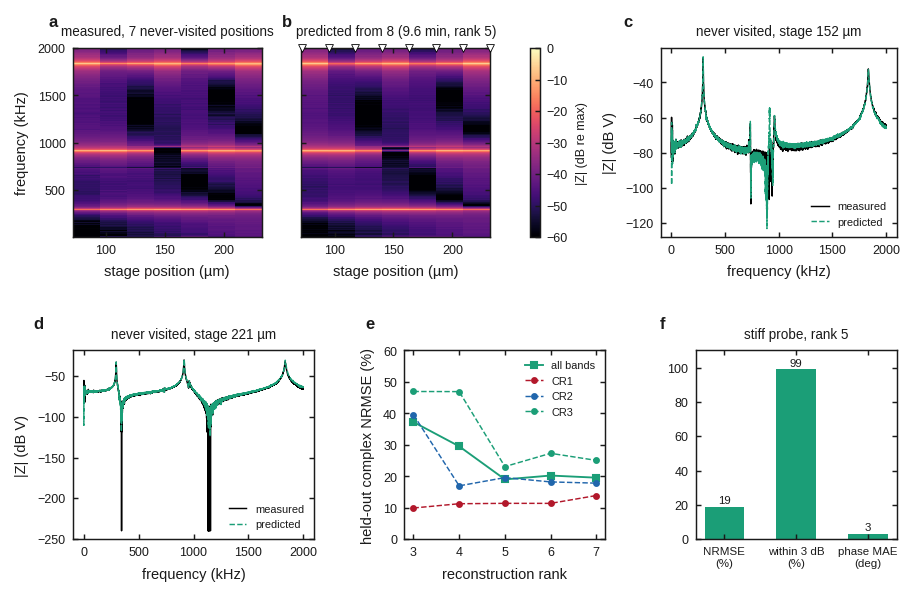

In [3]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.6))
gs = GridSpec(2, 5, figure=fig, width_ratios=[1, 1, 0.05, 0.22, 1.25], hspace=0.6, wspace=0.3)
ref = np.abs(v.Z[0]).max()
axa, axb = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
im = fp.map_db(axa, v.x_um, v.freq_Hz, v.Z[0], ref=ref, fmax=2000, colorbar=False)
axa.set_title(f"measured, {len(v.x_um)} never-visited positions", fontsize=6.5)
fp.map_db(axb, v.x_um, v.freq_Hz, Zp, ref=ref, fmax=2000, colorbar=False)
fp.mark_positions(axb, d.x_um)
axb.set_title(f"predicted from {len(d.x_um)} (9.6 min, rank {r})", fontsize=6.5); axb.set_ylabel(""); axb.set_yticklabels([])
for ax in (axa, axb):
    ax.set_xlabel("stage position (µm)")
cb = fig.colorbar(im, cax=fig.add_subplot(gs[0, 2])); cb.set_label("|Z| (dB re max)", fontsize=6)
fp.panel_label(axa, "a", dx=-0.08, dy=1.1); fp.panel_label(axb, "b", dx=-0.05, dy=1.1)

def spec(ax, j, lab):
    m = v.freq_Hz <= 2.0e6
    ax.plot(v.freq_Hz[m] / 1e3, 20 * np.log10(np.abs(v.Z[0, j][m]) + 1e-12), color=fp.C["meas"], lw=0.7, label="measured")
    ax.plot(v.freq_Hz[m] / 1e3, 20 * np.log10(np.abs(Zp[j][m]) + 1e-12), "--", color=fp.C["lowrank"], lw=0.7, label="predicted")
    ax.set_xlabel("frequency (kHz)"); ax.set_ylabel("|Z| (dB V)")
    ax.legend(loc="lower right", fontsize=5.3, handlelength=1.6)
    ax.set_title(f"never visited, stage {v.x_um[j]:.0f} µm", fontsize=6.5)
    fp.panel_label(ax, lab, dx=-0.12, dy=1.1)
j = len(v.x_um) // 2
spec(fig.add_subplot(gs[0, 4]), j, "c")
g2 = gs[1, :].subgridspec(1, 3, wspace=0.42, width_ratios=[1.2, 1, 1])
axd, axe, axf = (fig.add_subplot(g2[0, i]) for i in range(3))
spec(axd, len(v.x_um) - 1, "d")
# e  error vs rank (overall and per band)
axe.plot(Q["rank"], Q.nrmse, "s-", color="#1b9e77", ms=3, lw=0.9, label="all bands")
for b in ("CR1", "CR2", "CR3"):
    axe.plot(Q["rank"], Q[f"nrmse_{b}"], "o--", color=fp.C[b.lower()], ms=2.3, lw=0.7, label=b)
axe.set_xlabel("reconstruction rank"); axe.set_ylabel("held-out complex NRMSE (%)"); axe.set_ylim(0, 60)
axe.legend(loc="upper right", fontsize=5.3, handlelength=1.6)
fp.panel_label(axe, "e", dx=-0.15, dy=1.1)
# f  summary scores at the best rank
labs = ["NRMSE\n(%)", "within 3 dB\n(%)", "phase MAE\n(deg)"]
vals = [best.nrmse, 100 * best.within_3dB, best.phase_mae_deg]
axf.bar(range(3), vals, width=0.55, color="#1b9e77")
for i, y in enumerate(vals):
    axf.text(i, y + 2, f"{y:.0f}", ha="center", fontsize=5.5)
axf.set_xticks(range(3)); axf.set_xticklabels(labs, fontsize=5.5); axf.set_ylim(0, 110)
axf.set_title(f"stiff probe, rank {r}", fontsize=6.5)
fp.panel_label(axf, "f", dx=-0.15, dy=1.1)
fp.save(fig, "Fig4_live_fmm_stiff_only")